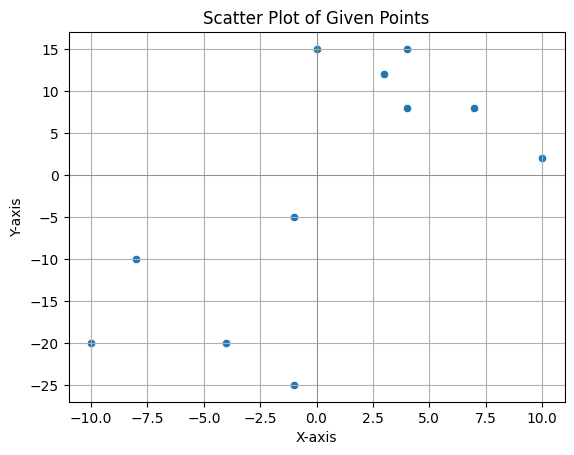

In [1]:
import seaborn as sns
import pandas as pd
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
points=(10,2),(4,15),(0,15),(3,12),(7,8),(4,8),(-1,-5),(-8,-10),(-10,-20),(-4,-20),(-1,-25)
df = pd.DataFrame(points, columns=['x', 'y'])
sns.scatterplot(data=df, x='x', y='y')
plt.title('Scatter Plot of Given Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

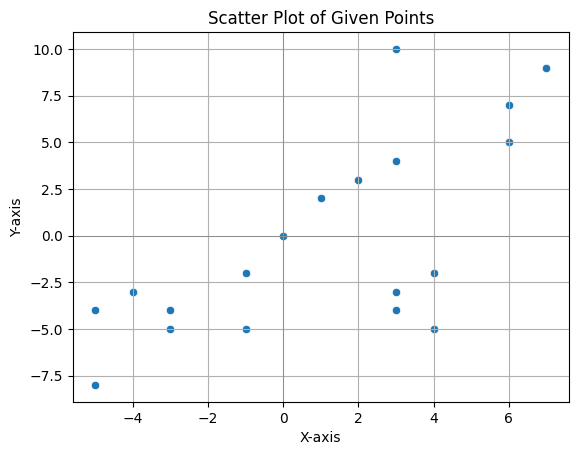

In [2]:


points =(1,2),(2,3),(-1,-2),(3,4),(4,-2),(3,-3),(-5,-4),(3,10),(-3,-4),(7,9),(6,5),(3,-4),(-4,-3),(-1,-5),(-5,-8),(6,7),(4,-5),(0,0),(-3,-5)
df = pd.DataFrame(points, columns=['x', 'y'])
sns.scatterplot(data=df, x='x', y='y')
plt.title('Scatter Plot of Given Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

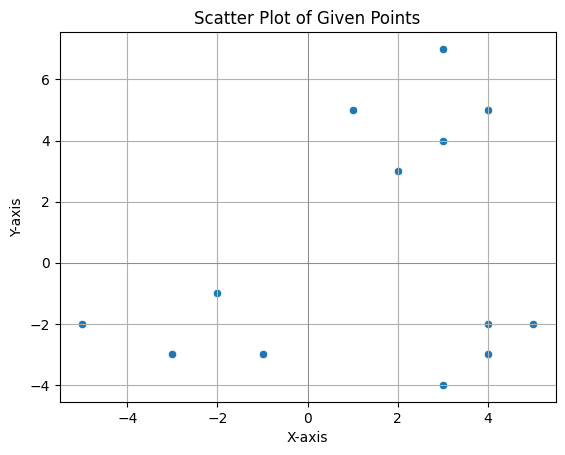

In [3]:
import seaborn as sns
import pandas as pd

points = [(3, -4), (2, 3), (-5, -2), (-3, -3), (3, 7), (5, -2), (4, 5), (-2, -1), (3, 4), (1, 5), (-1, -3), (4, -2), (4, -3)]

df = pd.DataFrame(points, columns=['x', 'y'])
sns.scatterplot(data=df, x='x', y='y')
plt.title('Scatter Plot of Given Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

In [4]:
!gdown "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

Downloading...
From: https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
To: c:\Users\dipty\ipynb\Courses\Scaler_ML_self\4ML_adv_supervised\1\E-commerce.csv

  0%|          | 0.00/140k [00:00<?, ?B/s]
100%|██████████| 140k/140k [00:00<00:00, 965kB/s]
100%|██████████| 140k/140k [00:00<00:00, 961kB/s]


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [8]:
X=df.drop("ID",axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   n_clicks                 2500 non-null   int64  
 1   n_visits                 2500 non-null   int64  
 2   amount_spent             2500 non-null   float64
 3   amount_discount          2500 non-null   float64
 4   days_since_registration  2500 non-null   int64  
 5   profile_information      2500 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 117.3 KB


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X)
X=scaler.transform(X)

In [10]:
from sklearn.cluster import KMeans

k = 4 ## arbitrary value
kmeans = KMeans(n_clusters=k,random_state = 42)
y_pred = kmeans.fit_predict(X)
print(y_pred[:5])

[3 3 0 2 3]


In [11]:
print(kmeans.cluster_centers_)

[[0.45420614 0.47552747 0.20419432 0.43879674 0.55639781 0.38103402]
 [0.16972077 0.2333873  0.49519562 0.03295739 0.38546526 0.36577318]
 [0.43951898 0.45250413 0.21523292 0.46553245 0.23500801 0.2938361 ]
 [0.27859127 0.31899857 0.09864364 0.05688261 0.3900433  0.33664185]]


In [12]:
clusters = pd.DataFrame(X, columns=df.drop("ID",axis=1).columns)
clusters['label'] = kmeans.labels_
clusters.head(3)

,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information,label
0,0.066890,0.220884,0.032571,0.013013,0.453307,0.401709,3
1,0.412207,0.144578,0.097333,0.002343,0.443580,0.290598,3
2,0.392977,0.369478,0.176234,0.347685,0.480545,0.699145,0


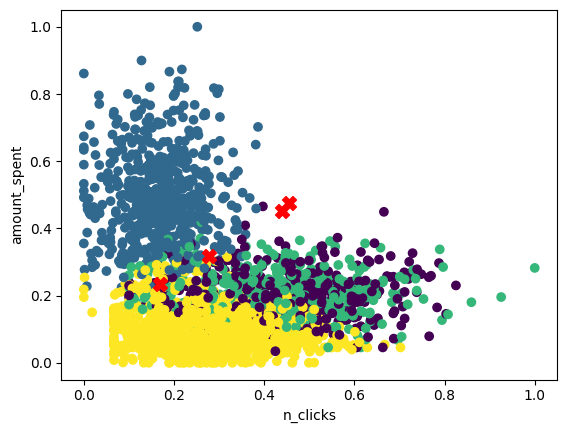

In [13]:
def viz_clusters(kmeans):
    # plt.scatter(clusters['n_clicks'], clusters['amount_spent'], c=clusters['label'])
    plt.scatter(clusters['n_clicks'], clusters['amount_spent'], c=kmeans.labels_)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                color="red",
                marker="X",
                s=100)
    plt.xlabel('n_clicks')
    plt.ylabel('amount_spent')

viz_clusters(kmeans)

In [14]:
kmeans_iter1 = KMeans(n_clusters=3, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter3 = KMeans(n_clusters=8, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter4 = KMeans(n_clusters=20, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)
kmeans_iter4.fit(X)

KMeans(init='random', n_clusters=20, n_init=1, random_state=0)

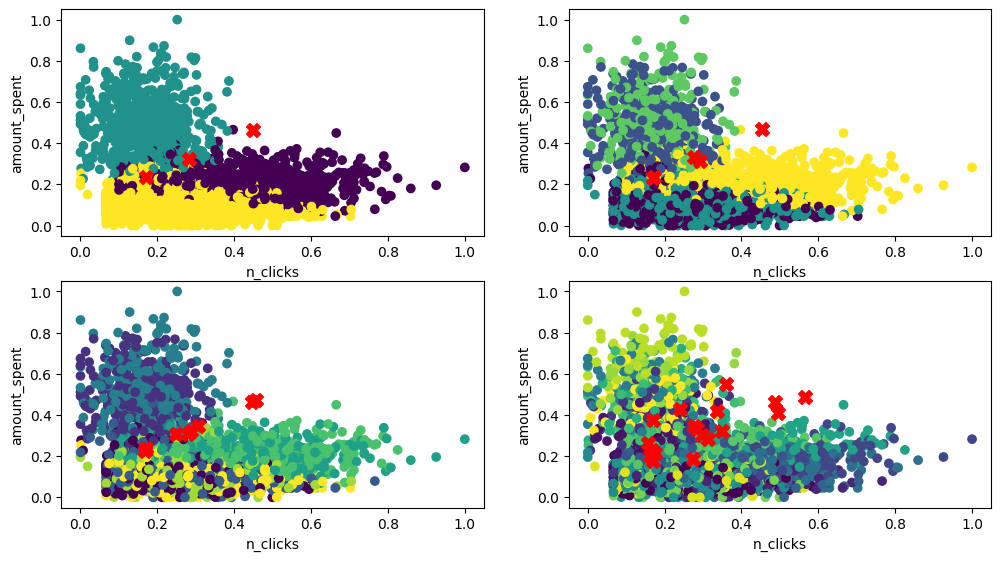

In [15]:
plt.figure(figsize=(12,10))

plt.subplot(321)
viz_clusters(kmeans_iter1)

plt.subplot(322)
viz_clusters(kmeans_iter2)

plt.subplot(323)
viz_clusters(kmeans_iter3)

plt.subplot(324)
viz_clusters(kmeans_iter4)

In [16]:
kmeans_iter1.inertia_, kmeans_iter2.inertia_, kmeans_iter3.inertia_, kmeans_iter4.inertia_,

(280.1650962612106, 234.85005987694075, 193.00182851000525, 140.56076784109885)

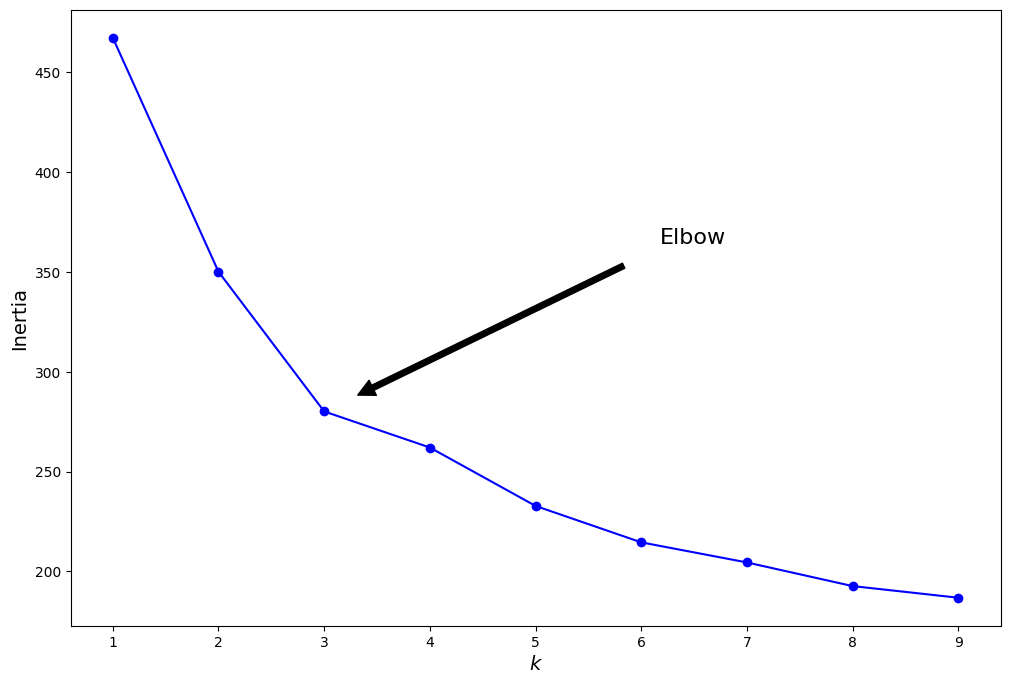

CPU times: total: 438 ms
Wall time: 353 ms


In [17]:
%%time
# Inertia = Within Cluster Sum of Squares
max_k = 10
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, max_k)]

inertias = [model.inertia_ for model in kmeans_per_k]
##################################
plt.figure(figsize=(12, 8))
plt.plot(range(1, max_k), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(3, inertias[2]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.show()

In [18]:
# confused between 3 and 4?
# pick higher silhouette_score

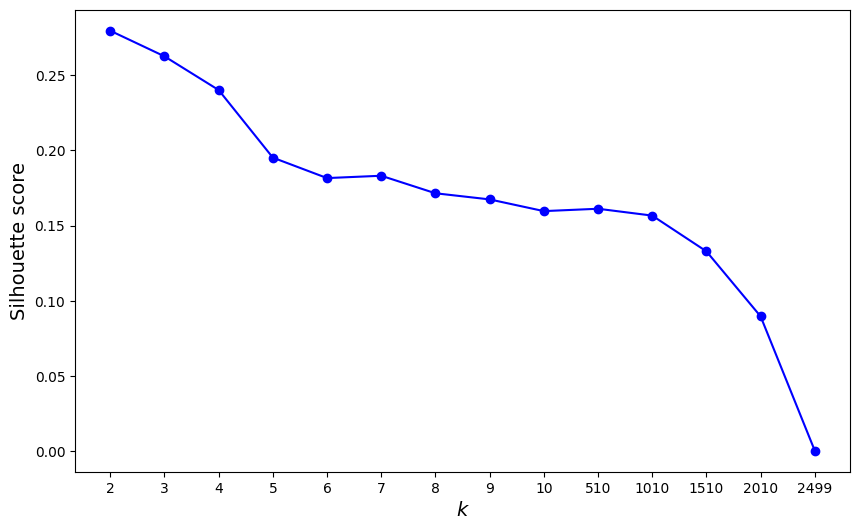

CPU times: total: 5.27 s
Wall time: 3.4 s


In [19]:
%%time
from sklearn.metrics import silhouette_score
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

max_k = 10
Ks = list(range(2,max_k)) + list(range(max_k,len(X)-1, 500)) + [len(X)-1]
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in Ks]

## plot for different values of K
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(Ks)+1), silhouette_scores, "bo-")
plt.xticks(ticks=range(1, len(Ks)+1), labels=Ks)
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

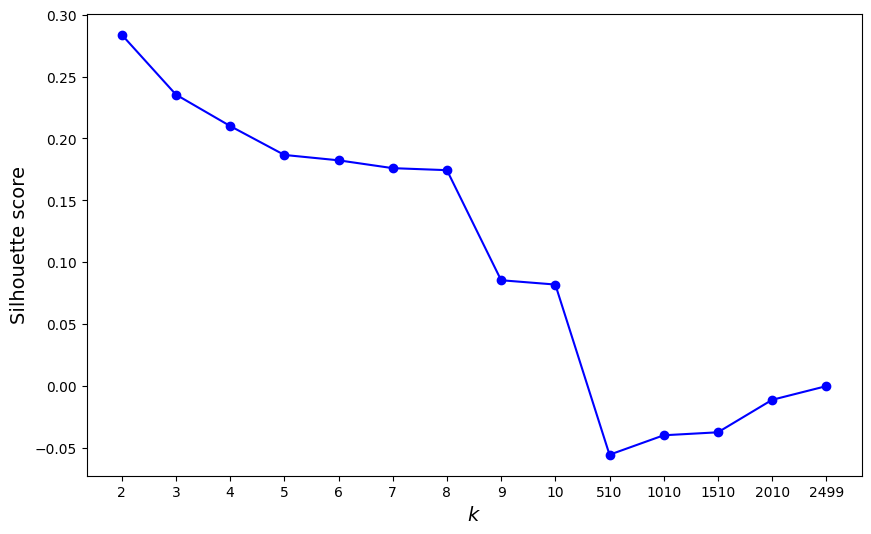

CPU times: total: 2.03 s
Wall time: 1.45 s


In [20]:
%%time
from sklearn.metrics import silhouette_score
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

max_k = 10
Ks = list(range(2,max_k)) + list(range(max_k,len(X)-1, 500)) + [len(X)-1]
kmeans_per_k = [KMeans(n_clusters=k, max_iter=1, n_init=1, init=[X[0]]*k).fit(X)
                for k in Ks]

## plot for different values of K
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(Ks)+1), silhouette_scores, "bo-")
plt.xticks(ticks=range(1, len(Ks)+1), labels=Ks)
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

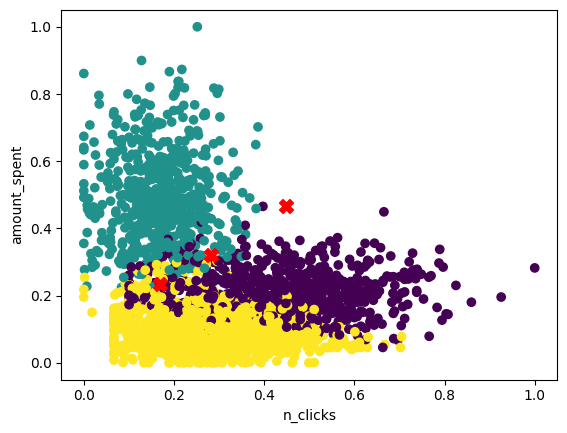

In [21]:
viz_clusters(KMeans(n_clusters=3, random_state=42).fit(X))

In [22]:
# import hierarchical clustering libraries
from sklearn.cluster import AgglomerativeClustering
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

# create clusters
# hc_2020 = AgglomerativeClustering(n_clusters=4, affinity = 'euclidean')
# y_pred = hc_2020.fit_predict(df)

![](https://miro.medium.com/v2/resize:fit:720/1*oF00T9hCGpr6N-1zm2M1nw.gif)

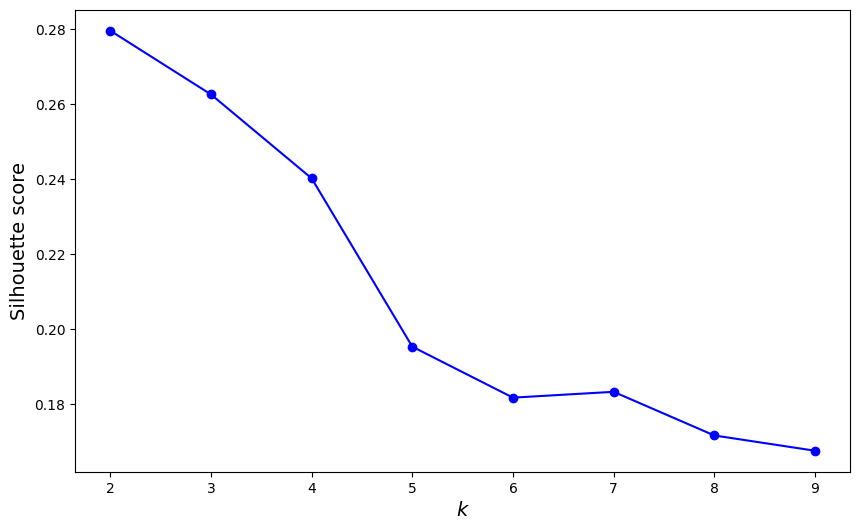

CPU times: total: 1.11 s
Wall time: 865 ms


In [23]:
%%time
from sklearn.metrics import silhouette_score
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

max_k = 10
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, max_k)]

## plot for different values of K
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.show()